## <span style="color:blue"> Lezione 9 </span>



In [1]:

import matplotlib.pyplot as plt


import numpy as np

parent_folder="l_09_all_es/OUTPUT/"

### <span style="color:DodgerBlue"> Esercizio 9.1 </span>



Il problema del commesso viaggiatore è il seguente: sono date $R$ città disposte su una mappa (ossia punti nel piano cartesiano) e si vuole trovare il miglior (più breve) percorso che partendo da una città fissata visiti tutte le altre una e una sola volta, per ritornare alla fine al punto di partenza. La funzione costo da minimizzare è la lunghezza del percorso: 
$$
L^{(1)}(\vec{x}_0, \vec{x}_1, \dots, \vec{x}_{R-1}) = \sum_{i=0}^{R-1} |\vec{x}_i-\vec{x}_{i+1}|
$$

dove $\vec{x}_i$ rappresenta la posizione dell'i-esima città del percorso e $\vec{x}_R=\vec{x}_0$.

Lo si è affrontato tramite un algoritmo genetico, un algoritmo metauristico ispirato al processo biologico dell'evoluzione. 

Si è creata una popolazione di $M$ cromosomi di $R+1$ geni ciascuno. Ogni gene assume un valore da $0$ a $R-1$ pari all'indice di una città sulla mappa. 
Il primo e ultimo gene sono, per ogni cromosoma, settati al valore $0$, indicando la partenza da una città fissata e il ritorno ad essa. 
Gli altri geni costituiscono una permutazione dell'array $[1,...,R-1]$. Il cromosoma, quindi, specifica un percorso circolare sulla mappa. (Ad esempio, per $R=5$ città, un percorso potrebbe essere $p=[0,1,3,2,4,0]$, corrispondente a visitare la città 1 dopo quella di partenza (0), poi la 3, la 2, la 4 e infine tornare alla città di partenza.) 

Ad ogni step dell'algoritmo viene creata una nuova generazione con le seguenti regole: 
1. Si ordina la popolazione in ordine crescente di lunghezza del percorso ($L^{(1)}(\vec{x}_0, \vec{x}_1, \dots, \vec{x}_{R-1})$) . 
2. Si selezionano due genitori con la regola $j=\mathrm{int}(M r^p)$, con $j$ indice dell'individuo, $M$ numero di individui, $p$ parametro e $r$ un numero casuale estratto in $[0,1)$ con probabilità uniforme. 
3. Con probabilità $P_x$ si effettua il crossover tra i genitori. 
4. Con probabilità $P_m$ si muta il primo figlio, sempre con probabilità $P_m$ si muta il secondo figlio.
5. I percorsi risultanti vengono aggiunti alla nuova generazione. 
6. Si ripete dal punto 2. al punto 5. finché la nuova generazione non ha $M$ individui. A quel punto si riparte dal punto 1. 


Il crossover consiste nel scegliere randomicamente un punto di taglio (escludendo il primo e l'ultimo indice) e tagliare ad esso entrambi i genitori, eliminando la parte a destra del taglio. Ciascuno dei due viene poi completato con le città mancanti prese nell'ordine in cui compaiono nell'altro genitore. 

Le mutazioni sono di quattro tipi. Esse agiscono solo sul corpo interno del cromosoma, ossia escludendo il primo e ultimo indice, fissati a zero. 
1. _Swap_ : si selezionano randomicamente con probabilità uniforme due indici interni del cromosoma, e si scambiano i valori contenuti in essi
2. _Shift_ : si selezionano randomicamente con probabilità uniforme due indici, $i_1$ e $i_2$ ($i_1 < i_2$), e una lunghezza $m$ (con i dovuti controlli sulle scelte). Dopodichè, si trasla circolarmente la sequenza lunga $m$ che ha come primo indice $i_1$, di $i_2$ - $i_1$ passi. 
3. _Reverse_: si selezionano randomicamente con probabilità uniforme due indici interni, $i_1$ e $i_2$ del cromosoma e si inverte l'ordine della sequenza che ha come primo indice $i_1$ e come ultimo indice $i_2$.
4. _Permutate_:  si selezionano randomicamente con probabilità uniforme due indici, $i_1$ e $i_2$ ($i_1 < i_2$), e una lunghezza $m$ (con i dovuti controlli sulle scelte). Dopodichè, si scambia la sequenza lunga $m$ che ha come primo indice $i_1$ con la sequenza lunga $m$ che ha come primo indice $i_2$. 

Il tipo di mutazione viene selezionato con un "dado truccato": si suddivide l'intervallo $[0,1)$ in quattro sottointervalli di lunghezza differente, 
controllabile tramite i parametri $S_w, S_s, S_r, S_p$, che rappresentano la frazione di mutazione di tipo _swap,shift,reverse,permutate_ rispetto al totale. Ovviamente, la somma di questi parametri deve dare $1$. 


Sono stati scelti come parametri:
- Probabilità di mutazione: $P_m = 0.1$
- Probabilità di crossover: $P_x = 0.8$
- Esponente di selezione: $p = 5.0$
- Frazioni di mutazione:
    - _swap_ $S_w = 0.05$
    - _reverse_ $S_r = 0.5$
    - _permutate_ $S_p= 0.05$ 
    - _shift_ $S_s = 0.4$



L'algoritmo è stato testato prima su $R=34$ città disposte randomicamente (probabilità uniforme) su di una circonferenza, problema per cui la soluzione ottimale è evidente. Successivamente, lo si è utilizzato per cercare il miglior percorso in grado di unire $R=34$ città disposte randomicamente (probabilità uniforme) dentro un quadrato.

### Città sulla circonferenza



Il raggio della circonferenza è stato preso $r=1$ e sono state utilizzate $N=500$ generazioni di $M=200$ individui ciascuna. 

La cella sottostante carica i dati: le posizioni delle città, la lunghezza del miglior percorso di ogni generazione e il percorso stesso.

In [2]:
C_cities=np.loadtxt(f"{parent_folder}cities_on_circle.csv")



cols=range(3,3 + len(C_cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1

#carica la lunghezza media della metà migliore della popolazione per ogni generazione e la lunghezza del miglior percorso 
C_avg_len,C_best_len=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=(1,2),unpack=True,skiprows=1)

C_best_path=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=cols,skiprows=len(C_best_len))#carica solo l'ultimo percorso (il migliore di tutti)


C_gen=np.arange(1,len(C_best_len)+1)


La cella sottostante grafica l'andamento della lunghezza del miglior percorso di ogni generazione in funzione delle stesse (a sinistra) e il miglior percorso dell'ultima generazione (a destra).

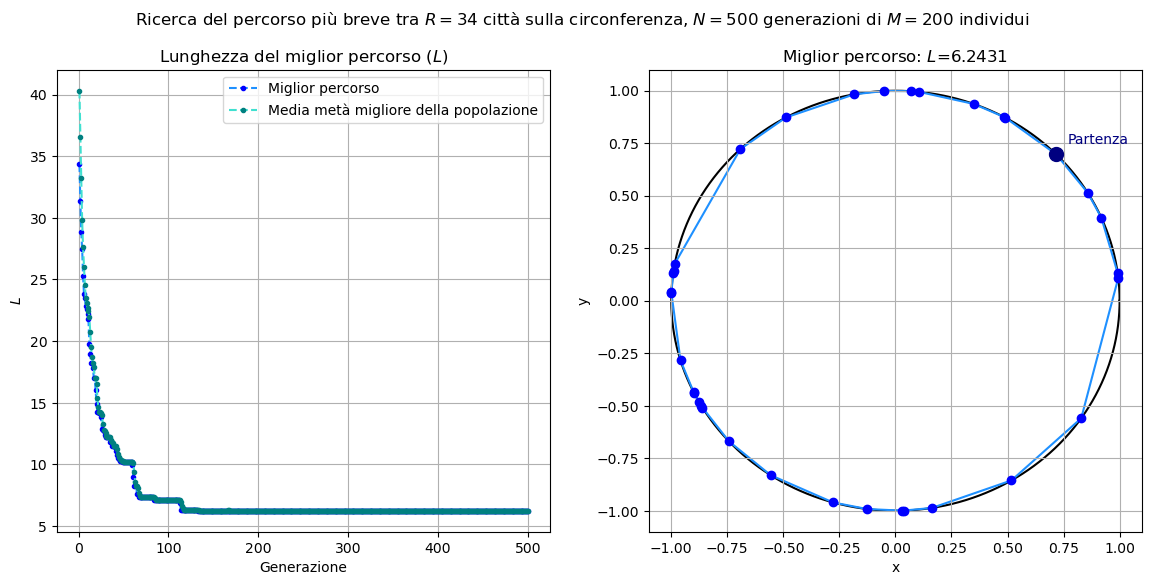

In [3]:
R=1#Raggio della circonferenza


fig,axs=plt.subplots(1,2,figsize=[14,6])


axs[0].plot(C_gen,C_best_len,"--.",mfc="blue",mec="blue",color="dodgerblue",label="Miglior percorso")
axs[0].plot(C_gen,C_avg_len,"--.",mfc="teal",mec="teal",color="turquoise",label="Media metà migliore della popolazione")

axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()


theta=np.linspace(0,2*np.pi,1000)
axs[1].plot(R*np.cos(theta),R*np.sin(theta),color="black",zorder=0)#circonferenza, per confronto

axs[1].scatter(C_cities[:,0],C_cities[:,1],color="blue",zorder=2)#città 

axs[1].scatter(C_cities[0,0],C_cities[0,1],color="navy",s=100,zorder=2)#città di partenza

axs[1].text(C_cities[0,0] + 0.05, C_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=C_best_path.astype(int)#ordine in cui le città vengono visitate (percorso)
axs[1].plot(C_cities[index,0],C_cities[index,1],color="dodgerblue",zorder=1) #unisce le città nell'ordine in cui vengono visitate


axs[1].grid()
axs[1].set_title(fr"Miglior percorso: $L$={C_best_len[-1]:.4f}")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
fig.suptitle(r"Ricerca del percorso più breve tra $R=34$ città sulla circonferenza, $N=500$ generazioni di $M=200$ individui");



E' evidente che il percorso ottenuto è il più corto possibile.

### Città nel quadrato


Il lato del quadrato è stato preso $L=1$ e sono state utilizzate $N=500$ generazioni di $M=200$ individui ciascuna.

La cella sottostante carica i dati: le posizioni delle città, la lunghezza del miglior percorso di ogni generazione e il percorso stesso.

In [4]:
SQ_cities=np.loadtxt(f"{parent_folder}cities_in_square.csv")



cols=range(3,3 + len(SQ_cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1

#carica la lunghezza media della metà migliore della popolazione per ogni generazione e la lunghezza del miglior percorso 
SQ_avg_len,SQ_best_len=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=(1,2),unpack=True,skiprows=1)

SQ_best_path=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=cols,skiprows=len(SQ_best_len))#carica solo l'ultimo percorso (il migliore di tutti)


SQ_gen=np.arange(1,len(SQ_best_len)+1)


La cella sottostante grafica l'andamento della lunghezza del miglior percorso di ogni generazione in funzione delle stesse (a sinistra) e il miglior percorso dell'ultima generazione (a destra).

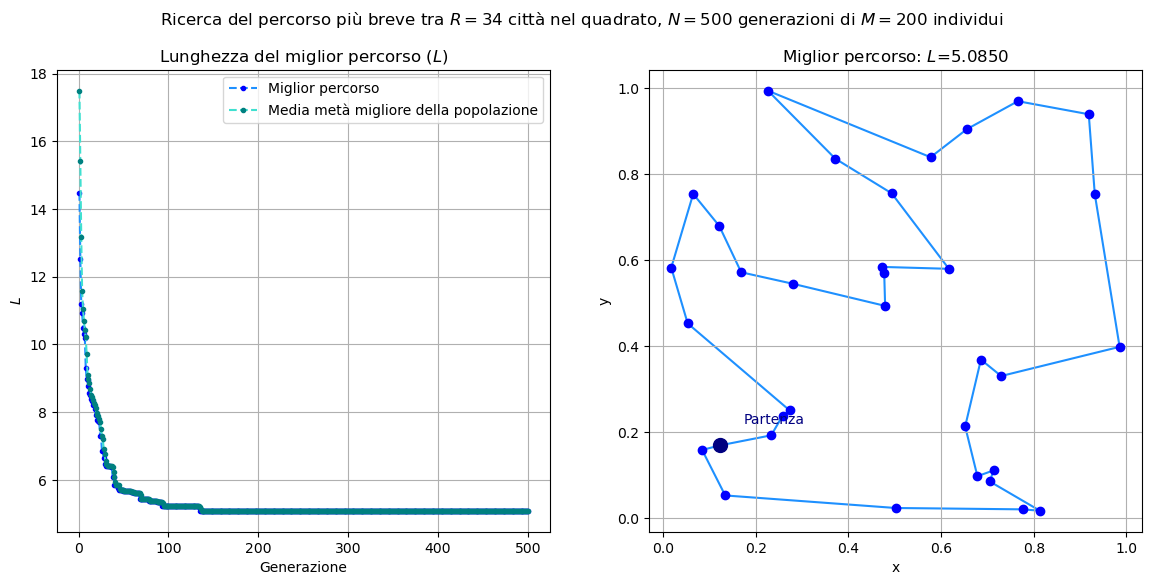

In [5]:


fig,axs=plt.subplots(1,2,figsize=[14,6])


axs[0].plot(SQ_gen,SQ_best_len,"--.",mfc="blue",mec="blue",color="dodgerblue",label="Miglior percorso")
axs[0].plot(SQ_gen,SQ_avg_len,"--.",mfc="teal",mec="teal",color="turquoise",label="Media metà migliore della popolazione")

axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()

axs[1].scatter(SQ_cities[:,0],SQ_cities[:,1],color="blue",zorder=2)#città 

axs[1].scatter(SQ_cities[0,0],SQ_cities[0,1],color="navy",s=100,zorder=2)#città di partenza

axs[1].text(SQ_cities[0,0] + 0.05, SQ_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=SQ_best_path.astype(int)#ordine in cui le città vengono visitate (percorso)
axs[1].plot(SQ_cities[index,0],SQ_cities[index,1],color="dodgerblue",zorder=1) #unisce le città nell'ordine in cui vengono visitate


axs[1].grid()
axs[1].set_title(fr"Miglior percorso: $L$={SQ_best_len[-1]:.4f}")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
fig.suptitle(r"Ricerca del percorso più breve tra $R=34$ città nel quadrato, $N=500$ generazioni di $M=200$ individui");




Non è più possibile dire con certezza se il percorso sia o meno il più corto possibile. Si può almeno notare che tutti gli incroci (indice di un percorso non ottimale) sono stati eliminati. 

Per meglio apprezzare il funzionamento dell'algoritmo sono state realizzate due animazioni che mostrano l'evoluzione del miglior percorso (della generazione) con la sua lunghezza in funzione della generazione. 

![Alt Text](Pictures/circonferenza.gif) 
![Alt Text](Pictures/quadrato.gif) 


Di seguito sono riportati i codici utilizzati per generarle. 

In [6]:
import matplotlib.animation as animation 

### Circonferenza

In [7]:
%%capture

C_paths=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=cols,skiprows=1)

fig,ax=plt.subplots(1,1,figsize=[6,6])

theta=np.linspace(0,2*np.pi,1000)
ax.plot(R*np.cos(theta),R*np.sin(theta),color="black",zorder=0)#circonferenza, per confronto
ax.scatter(C_cities[:,0],C_cities[:,1],color="blue",zorder=2)#città
ax.scatter(C_cities[0,0],C_cities[0,1],color="navy",s=100,zorder=2)#città di partenza
ax.text(C_cities[0,0] + 0.05, C_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=C_paths[0].astype(int)#ordine in cui le città vengono visitate (percorso)
path=ax.plot(C_cities[index,0],C_cities[index,1],color="dodgerblue",zorder=1)[0]#unisce le città nell'ordine in cui vengono visitate
ax.set_title(fr"Generazione: 1  | Lunghezza miglior percorso $L$={C_best_len[0]:.4f}")

ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")


def update(frame):#funzione di aggiornamento (per funcanimation)
    index=C_paths[frame].astype(int)#ordine in cui le città vengono visitate (percorso)
    path.set_xdata(C_cities[index,0])
    path.set_ydata(C_cities[index,1])
    ax.set_title(fr"Generazione: {frame}  | Lunghezza miglior percorso $L$={C_best_len[frame]:.4f}")

    return path



anim = animation.FuncAnimation(fig=fig, func=update, frames=200, interval=30) 
#anim.save("./Pictures/circonferenza.gif") # (commentato per evitare di sovrascrivere il file)

### Quadrato

In [8]:
%%capture

SQ_paths=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=cols,skiprows=1)

fig,ax=plt.subplots(1,1,figsize=[6,6])

ax.scatter(SQ_cities[:,0],SQ_cities[:,1],color="blue",zorder=2)#città
ax.scatter(SQ_cities[0,0],SQ_cities[0,1],color="navy",s=100,zorder=2)#città di partenza
ax.text(SQ_cities[0,0] + 0.05, SQ_cities[0,1] + 0.03, "Partenza", fontsize=10, ha='right',color="navy")#segna la città di partenza

index=SQ_paths[0].astype(int)#ordine in cui le città vengono visitate (percorso)
path=ax.plot(SQ_cities[index,0],SQ_cities[index,1],color="dodgerblue",zorder=1)[0]#unisce le città nell'ordine in cui vengono visitate
ax.set_title(fr"Generazione: 1  | Lunghezza miglior percorso $L$={SQ_best_len[0]:.4f}")

ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")


def update(frame):#funzione di aggiornamento (per funcanimation)
    index=SQ_paths[frame].astype(int)#ordine in cui le città vengono visitate (percorso)
    path.set_xdata(SQ_cities[index,0])
    path.set_ydata(SQ_cities[index,1])
    ax.set_title(fr"Generazione: {frame}  | Lunghezza miglior percorso $L$={SQ_best_len[frame]:.4f}")

    return path



anim = animation.FuncAnimation(fig=fig, func=update, frames=200, interval=30) 
#anim.save("./Pictures/quadrato.gif") # (commentato per evitare di sovrascrivere il file)